<a href="https://colab.research.google.com/github/BagasArdiansaPutra/Pembelajaran-Mesin-2026/blob/main/TG4_244107020166_Bagas_Ardiansa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
JS04 - KLASTERISASI

In [ ]:
PRAKTIKUM 1 - KMeans

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('/content/Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


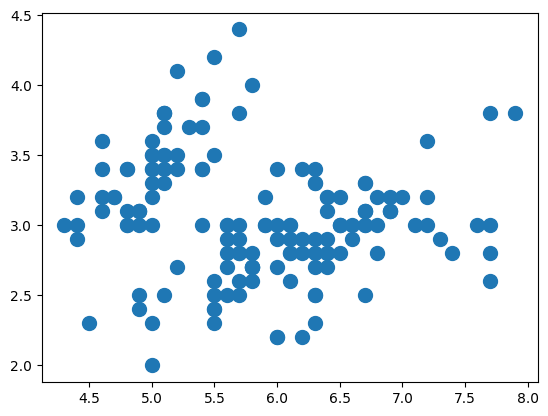

In [ ]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [ ]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

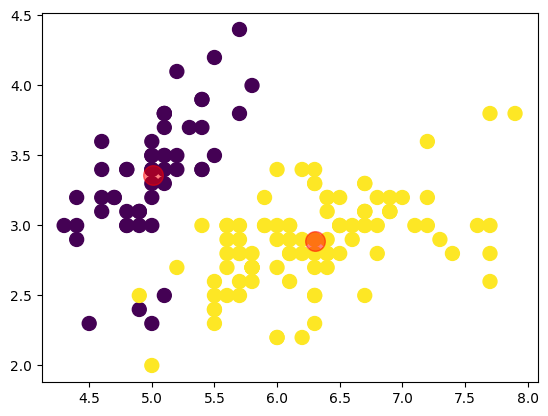

In [ ]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [ ]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


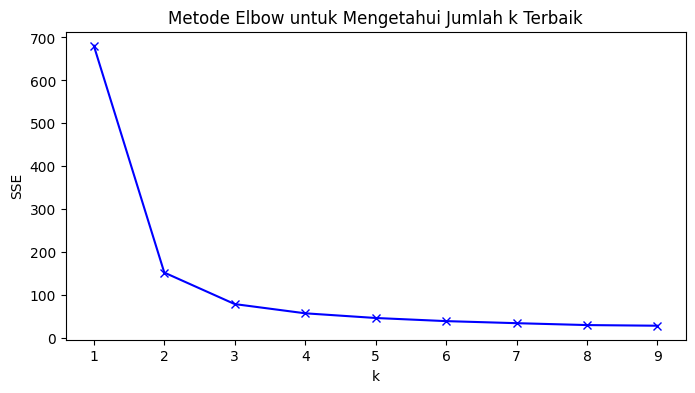

In [ ]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [ ]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.4732732654949
k=5; SSE=46.56163015873017
k=6; SSE=39.2778790000849
k=7; SSE=34.46540901771336
k=8; SSE=30.076048542249342
k=9; SSE=28.551016566766574


In [ ]:
PRAKTIKUM 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

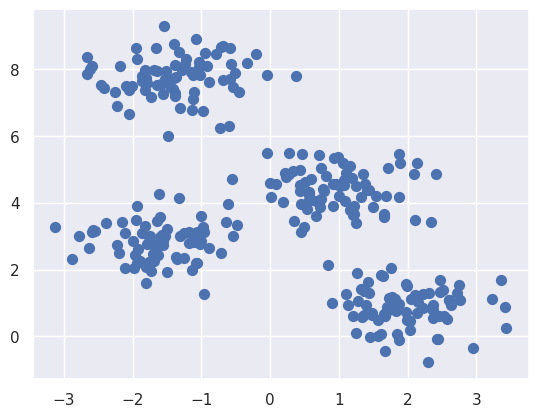

In [ ]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

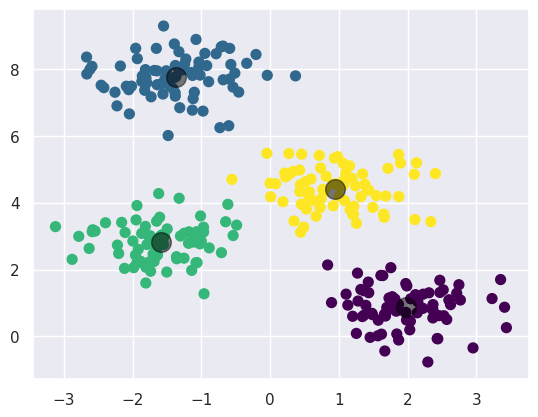

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

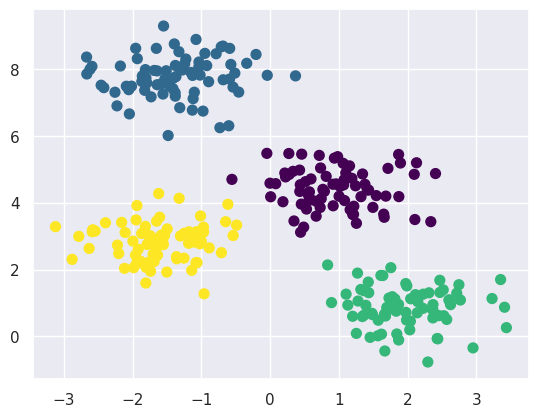

In [ ]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

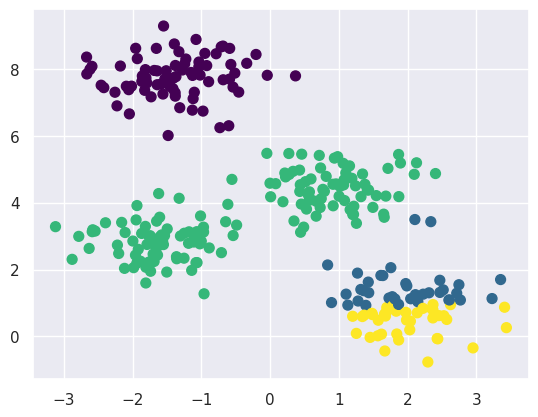

In [ ]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

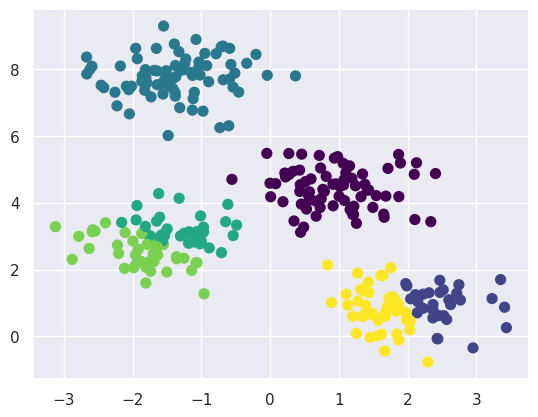

In [ ]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

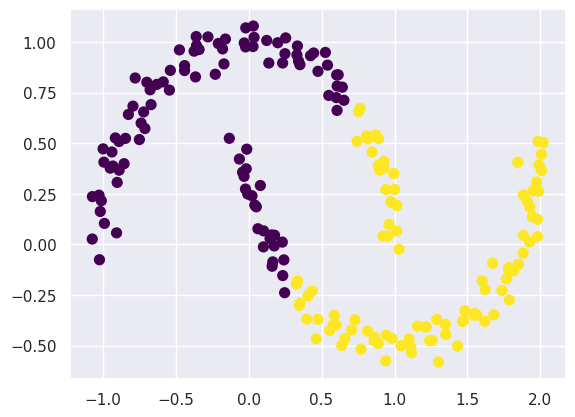

In [ ]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


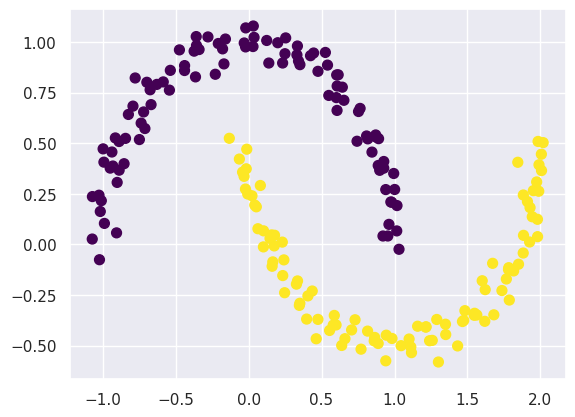

In [ ]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [ ]:
Contoh Kasus 1: Karakter Angka

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [ ]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

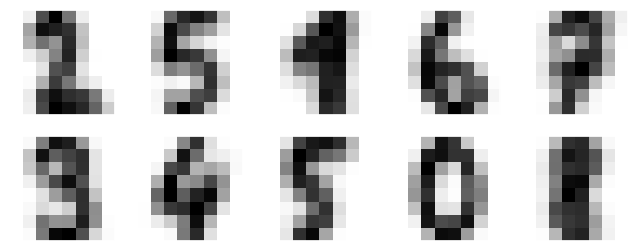

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [ ]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

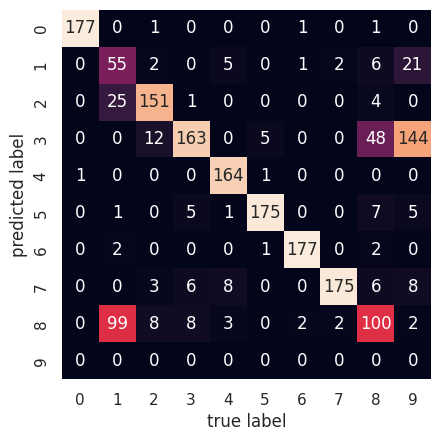

In [ ]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [ ]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

In [ ]:
Studi Kasus 2: Kompresi Citra

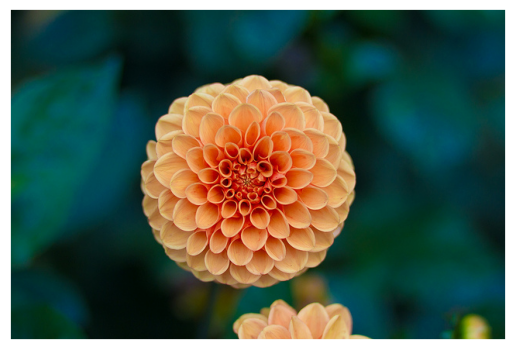

In [ ]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [ ]:
flower.shape

(427, 640, 3)

In [ ]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [ ]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

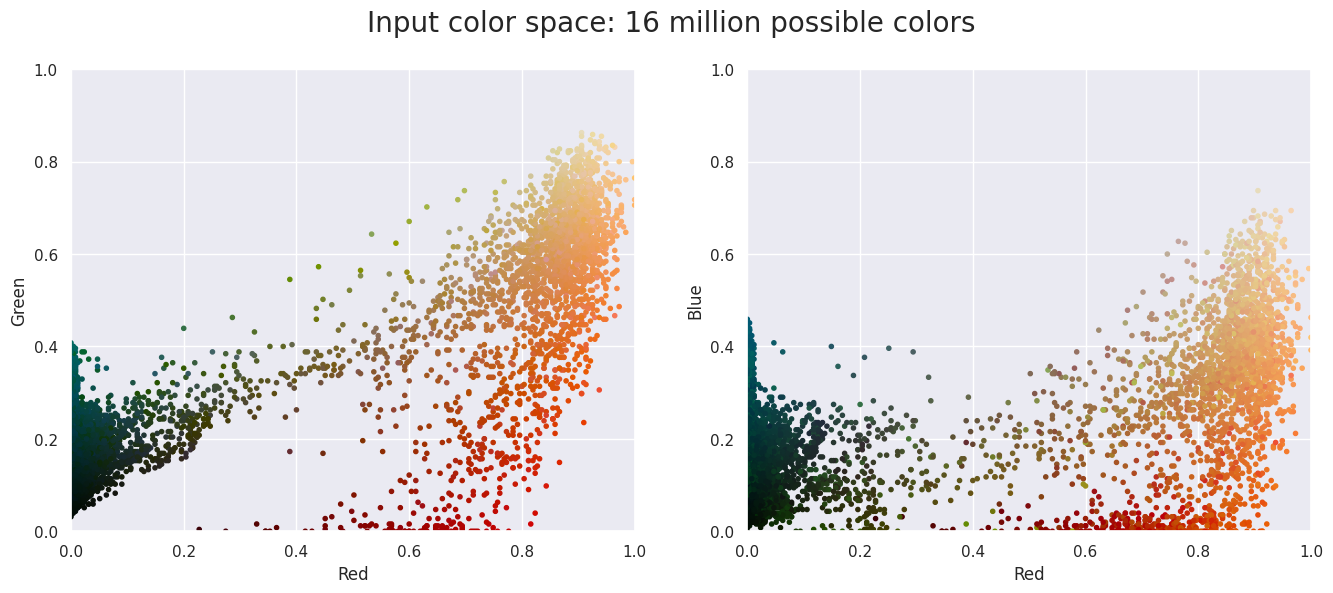

In [ ]:
plot_pixels(data, title='Input color space: 16 million possible colors')

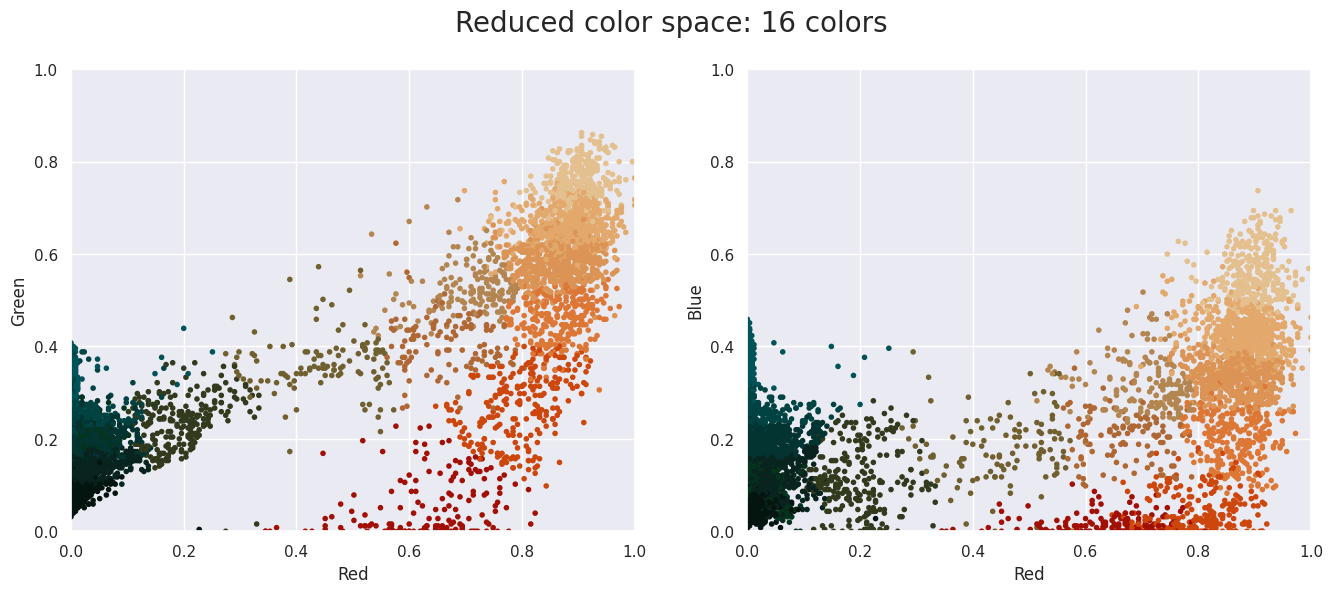

In [ ]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

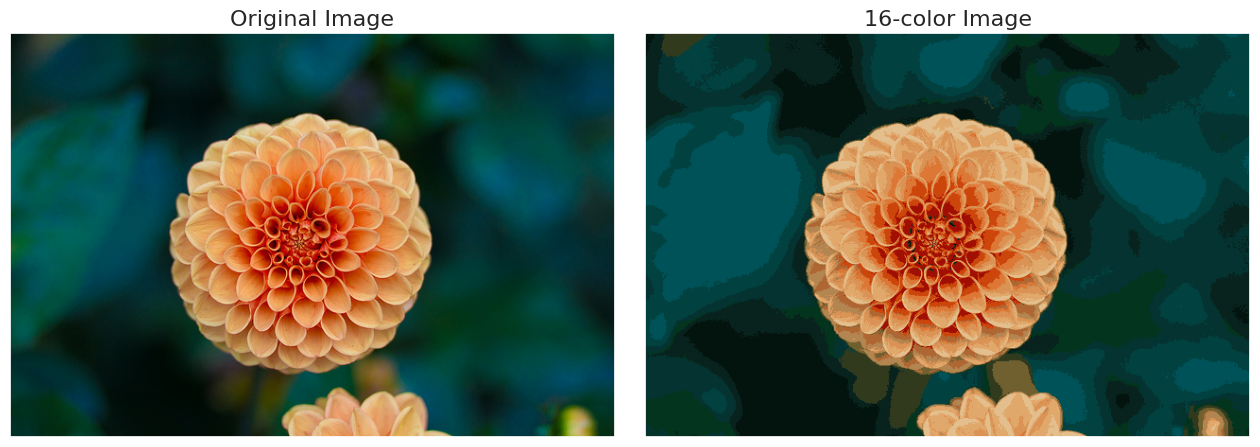

In [ ]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

In [ ]:
Praktikum 3

In [ ]:
Pembuatan Dataset Sintetis

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

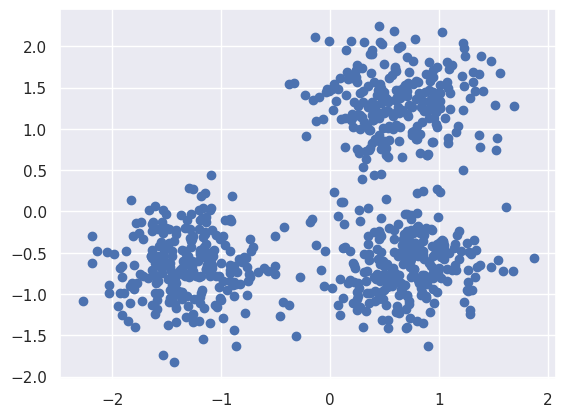

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [ ]:
Compute DBSCAN

In [ ]:
import numpy as np
from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


In [ ]:
Evaluasi Kualitas Klasterisasi

In [ ]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


In [ ]:
Visualisasi Hasil Klasterisasi

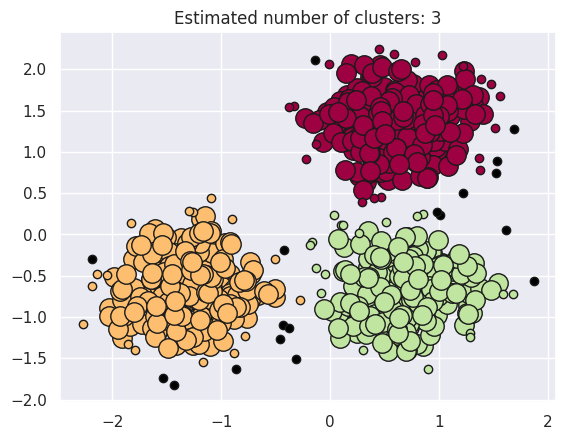

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [ ]:
TUGAS PRAKTIKUM

In [ ]:
Tugas K-Means
Buatlah sebuah model K-Means dengan ketentuan,

In [ ]:
1. Gunakan data 'Mall_Customers.csv'

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Memuat dataset
df = pd.read_csv('/content/Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)

In [10]:
x = df.iloc[:, 3:]

x.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
3.Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.

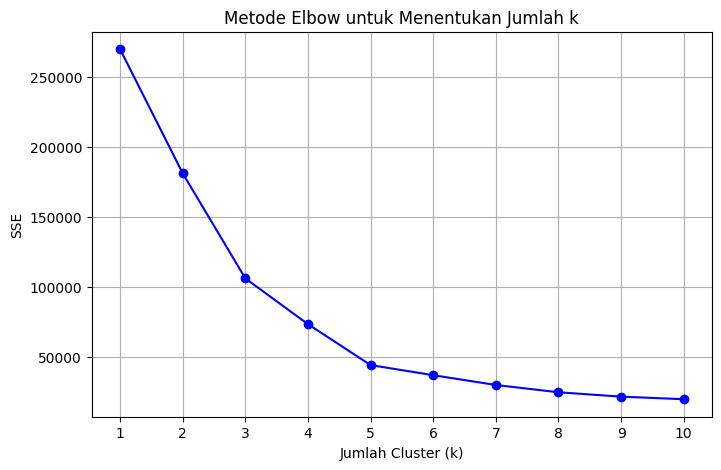

In [11]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
K_range = range(1, 11)

# Melakukan perulangan untuk mencoba k=1 hingga k=10
for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# visualisasi Metode Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker='o', linestyle='-', color='b')
plt.title('Metode Elbow untuk Menentukan Jumlah k')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE')
plt.xticks(K_range)
plt.grid(True)
plt.show()

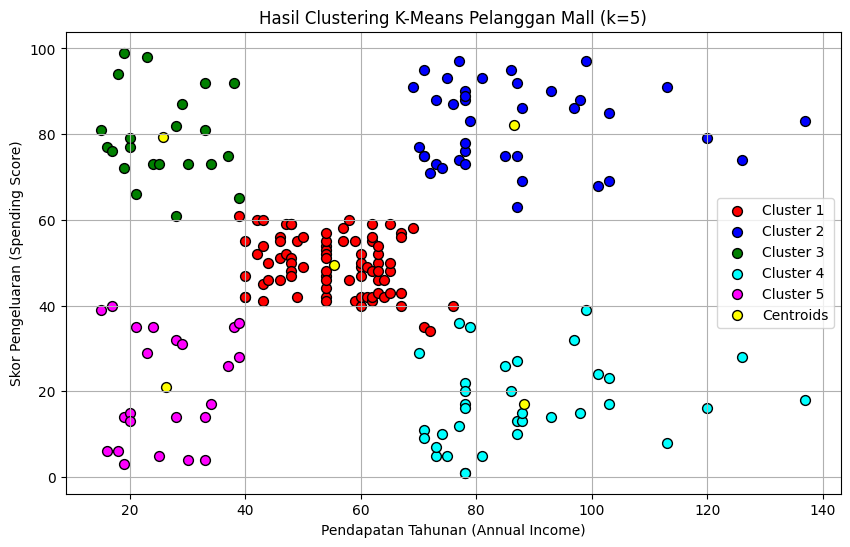

In [12]:
# Membuat model K-Means dengan k=5
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# Melatih model
y_kmeans = kmeans_final.fit_predict(X)

# Visualisasi hasil clustering
plt.figure(figsize=(10, 6))
warna = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=50, c=warna[i], label=f'Cluster {i+1}', edgecolors='black')

plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            s=200, c='yellow', marker='.', label='Centroids', edgecolors='black')

plt.title('Hasil Clustering K-Means Pelanggan Mall (k=5)')
plt.xlabel('Pendapatan Tahunan (Annual Income)')
plt.ylabel('Skor Pengeluaran (Spending Score)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Tugas DBSCAN

In [ ]:
1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.

In [13]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.59996716  0.31757343]
 [ 0.55020965 -1.42528284]
 [ 0.46649751 -1.26036633]
 [-0.14046604 -1.30173005]
 [-1.54557314  0.56836644]]


In [ ]:
2. Jalankan DBSCAN dengan eps=0.2, min_samples=5, hitung jumlah klaster & noise.

In [14]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5)
db.fit(X_scaled)

labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

n_noise = list(labels).count(-1)

print(f"Jumlah klaster yang terbentuk : {n_clusters}")
print(f"Jumlah titik noise            : {n_noise}")

Jumlah klaster yang terbentuk : 2
Jumlah titik noise            : 0


In [ ]:
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI,
Silhouette.

In [15]:
from sklearn import metrics

print(" Hasil Evaluasi DBSCAN ")
print(f"Homogeneity          : {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness         : {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure            : {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index  : {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Info : {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coeff     : {metrics.silhouette_score(X_scaled, labels):.3f}")

 Hasil Evaluasi DBSCAN 
Homogeneity          : 1.000
Completeness         : 1.000
V-measure            : 1.000
Adjusted Rand Index  : 1.000
Adjusted Mutual Info : 1.000
Silhouette Coeff     : 0.391


In [ ]:
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil,
  noise = hitam).

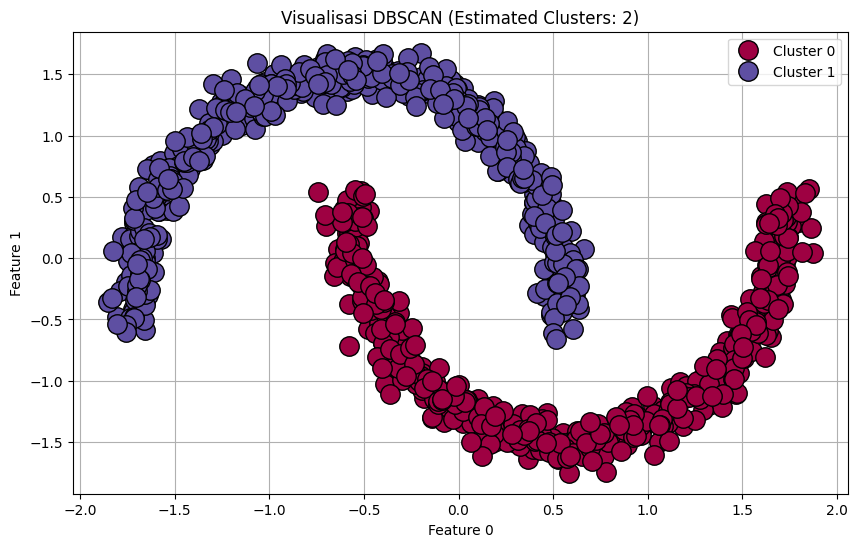

In [16]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)

core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(10, 6))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14, label=f'Cluster {k}' if k != -1 else 'Noise')

    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title(f'Visualisasi DBSCAN (Estimated Clusters: {n_clusters})')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

handles, labels_leg = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_leg, handles))
plt.legend(by_label.values(), by_label.keys())

plt.grid(True)
plt.show()

In [ ]:
5. Lakukan eksperimen:
eps = 0.05, 0.1, 0.3, 0.5
min_samples = 3, 10, 20
Catat perubahan klaster, noise, dan kualitas evaluasi.

In [17]:
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

X, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

eps_list = [0.05, 0.1, 0.3, 0.5]
min_samples_list = [3, 10, 20]

hasil_eksperimen = []

for eps in eps_list:
    for min_samples in min_samples_list:
        db_exp = DBSCAN(eps=eps, min_samples=min_samples)
        db_exp.fit(X_scaled)
        lbls = db_exp.labels_

        n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_noise = list(lbls).count(-1)

        if 1 < n_clusters < len(X_scaled):
            homo = metrics.homogeneity_score(labels_true, lbls)
            comp = metrics.completeness_score(labels_true, lbls)
            v_meas = metrics.v_measure_score(labels_true, lbls)
            ari = metrics.adjusted_rand_score(labels_true, lbls)
            ami = metrics.adjusted_mutual_info_score(labels_true, lbls)
            sil = metrics.silhouette_score(X_scaled, lbls)
        else:
            homo = comp = v_meas = ari = ami = sil = 0.0

        hasil_eksperimen.append({
            'eps': eps,
            'min_samples': min_samples,
            'Jumlah Klaster': n_clusters,
            'Jumlah Noise': n_noise,
            'Homogeneity': homo,
            'Completeness': comp,
            'V-measure': v_meas,
            'ARI': ari,
            'AMI': ami,
            'Silhouette': sil
        })
df_hasil = pd.DataFrame(hasil_eksperimen)
print(df_hasil.round(3).to_string(index=False))

 eps  min_samples  Jumlah Klaster  Jumlah Noise  Homogeneity  Completeness  V-measure   ARI   AMI  Silhouette
0.05            3              69           186        0.816         0.153      0.257 0.030 0.244       0.113
0.05           10               3           970        0.031         0.127      0.049 0.002 0.046      -0.294
0.05           20               0          1000        0.000         0.000      0.000 0.000 0.000       0.000
0.10            3               2            14        0.986         0.903      0.943 0.972 0.943       0.252
0.10           10               7            57        0.943         0.410      0.571 0.523 0.570       0.162
0.10           20               6           850        0.154         0.155      0.155 0.017 0.151      -0.360
0.30            3               2             0        1.000         1.000      1.000 1.000 1.000       0.391
0.30           10               2             0        1.000         1.000      1.000 1.000 1.000       0.391
0.30      

In [ ]:
- radius kecil (eps = 0.05), pola data gagal dikenali sehingga terpecah menjadi puluhan klaster kecil. Namun, pada radius optimal (eps = 0.30 dan 0.50), algoritma
sangat stabil dan berhasil membentuk tepat 2 klaster terlepas dari berapapun nilai min_samples yang digunakan.
- Menaikkan nilai min_samples pada radius yang sempit (eps = 0.05 atau 0.10) berakibat fatal karena memicu lonjakan noise hingga ratusan titik. Sebaliknya, pada jangkauan radius optimal, jumlah
noise sukses ditekan hingga hilang sepenuhnya (0 titik).
- Pada parameter optimal, lima metrik utama (Homogeneity, Completeness, V-measure, ARI, AMI) mencapai skor akurasi sempurna (1.000). Nilai Silhouette yang hanya mencapai 0.391 adalah hal wajar,
karena metrik ini dirancang untuk klaster berbentuk bulat (seperti K-Means) dan sering menilai rendah klaster berbentuk lengkungan (non-linear).